In [1]:
import brian2 as b2 # type: ignore
import matplotlib.pyplot as plt # type: ignore
%matplotlib inline

#### **Simple synapse**

We've created two neurons, each of which has the same differential equation but different values for parameters ``I`` and ``tau``. Neuron 0 has ``I = 2`` and ``tau = 10*ms`` which means that is driven to repeatedly spike at a fairly high rate. Neuron 1 has ``I = 0`` and ``tau = 100*ms`` which means that on its own it won't spike at all (the driving current I is 0).

The syntax ``on_pre = 'v_post += 0.2'`` means that when a spike occurs in the presynaptic neuron (hence ``on_pre``) it causes an instantaneous change to happen ``v_post += 0.2``. The ``_post`` means that the value of ``v`` referred to is the post-synaptic value, and it is increased by 0.2. So in total, what this model says is that whenever two neurons in G are connected by a synapse, when the source neuron fires a spike the target neuron will have its value of ``v`` increased by 0.2.

The line ``syn.connect(i = 0, j = 1)`` creates a synapse from neuron 0 to neuron 1.

In [2]:
b2.start_scope()

# Model equation
eqs = '''
dv/dt = (I-v)/tau : 1
I : 1 
tau : second
'''

# Neurons
group = b2.NeuronGroup(2, eqs, threshold = 'v>1', reset = 'v=0', method = 'exact')
group.I = [2, 0]
group.tau = [10, 100] * b2.ms

# Synapses 
syn = b2.Synapses(group, group, on_pre = 'v_post+=0.2')
syn.connect(i = 0, j = 1)

M = b2.StateMonitor(group, 'v', record = True)
b2.run(100 * b2.ms)

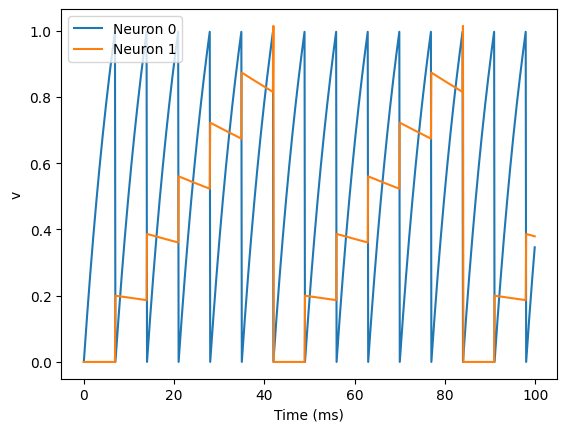

In [3]:
b2.plot(M.t / b2.ms, M.v[0], label = 'Neuron 0')
b2.plot(M.t / b2.ms, M.v[1], label = 'Neuron 1')
b2.xlabel('Time (ms)')
b2.ylabel('v')
b2.legend();

#### **Adding weights**

This example behaves very similarly to the previous example, but now there's a synaptic weight variable ``w``. The string ``'w:1'`` is an equation string, precisely the same as for neurons, that defines a single dimensionless parameter ``w``. We changed the behaviour on a spike to ``on_pre = 'v_post += w'`` now, so that each synapse can behave differently depending on the value of ``w``. 

In [4]:
b2.start_scope()

# Model equation
eqs = '''
dv/dt = (I-v)/tau : 1
I : 1
tau : second
'''

# Neurons
group = b2.NeuronGroup(3, eqs, threshold = 'v>1', reset = 'v=0', method = 'exact')
group.I = [2, 0, 0]
group.tau = [10, 100, 100] * b2.ms

# Synapses
syn = b2.Synapses(group, group, 'w:1', on_pre = 'v_post+=w')
syn.connect(i = 0, j = [1, 2])
syn.w = 'j*0.2'

M = b2.StateMonitor(group, 'v', record = True)
b2.run(50 * b2.ms)

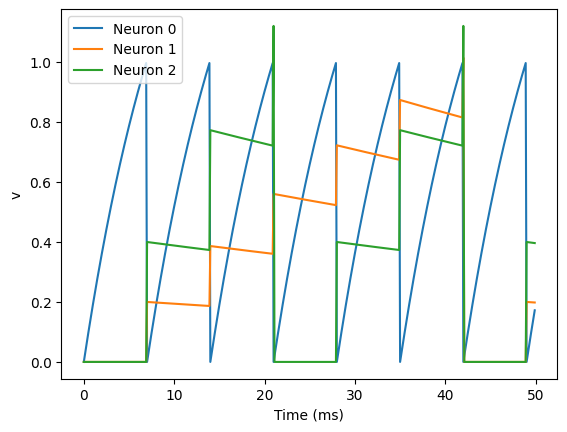

In [5]:
b2.plot(M.t / b2.ms, M.v[0], label = 'Neuron 0')
b2.plot(M.t / b2.ms, M.v[1], label = 'Neuron 1')
b2.plot(M.t / b2.ms, M.v[2], label = 'Neuron 2')
b2.xlabel('Time (ms)')
b2.ylabel('v')
b2.legend();

#### **Introducing a delay**

In [6]:
b2.start_scope()

# Model equation
eqs = '''
dv/dt = (I-v)/tau : 1
I : 1
tau : second
'''

# Neurons
group = b2.NeuronGroup(3, eqs, threshold = 'v>1', reset = 'v=0', method = 'exact')
group.I = [2, 0, 0]
group.tau = [10, 100, 100] * b2.ms

# Synapses
syn = b2.Synapses(group, group, 'w:1', on_pre = 'v_post+=w')
syn.connect(i = 0, j = [1, 2])
syn.w = 'j*0.2'
syn.delay = 'j*2*ms'

M = b2.StateMonitor(group, 'v', record = True)
b2.run(100 * b2.ms)

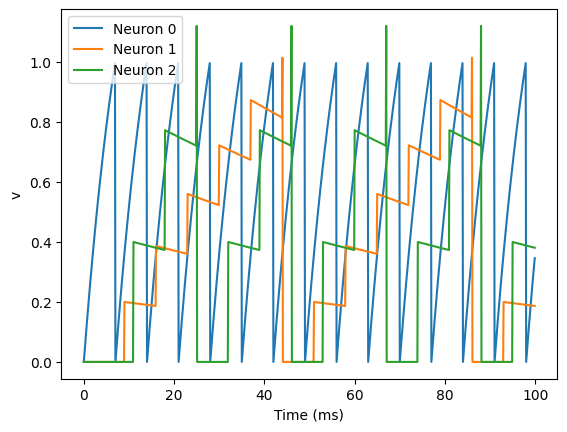

In [7]:
b2.plot(M.t / b2.ms, M.v[0], label = 'Neuron 0')
b2.plot(M.t / b2.ms, M.v[1], label = 'Neuron 1')
b2.plot(M.t / b2.ms, M.v[2], label = 'Neuron 2')
b2.xlabel('Time (ms)')
b2.ylabel('v')
b2.legend();

#### **More complex connectivity**

When many neurons are involved in the network, it becomes difficult to specify the synaptic connectivity explicitly. The line ``syn.connect(condition = 'i!=j', p = 0.2)`` will connect all pairs of neurons ``i`` and ``j`` with probability 0.2 as long as tge condition ``i!=j`` holds.

In [8]:
def visualise_connectivity(syn):
    Ns = len(syn.source)
    Nt = len(syn.target)
    b2.figure(figsize = (8, 3))
    b2.subplot(121)
    b2.plot(b2.zeros(Ns), b2.arange(Ns), 'ok', ms = 10)
    b2.plot(b2.ones(Nt), b2.arange(Nt), 'ok', ms = 10)
    for i, j in zip(syn.i, syn.j):
        b2.plot([0, 1], [i, j], '-k')
    b2.xticks([0, 1], ['Source', 'Target'])
    b2.ylabel('Neuron index')
    b2.xlim(-0.1, 1.1)
    b2.ylim(-1, max(Ns, Nt))
    b2.subplot(122)
    b2.plot(syn.i, syn.j, 'ok')
    b2.xlim(-1, Ns)
    b2.ylim(-1, Nt)
    b2.xlabel('Source neuron index')
    b2.ylabel('Target neuron index')

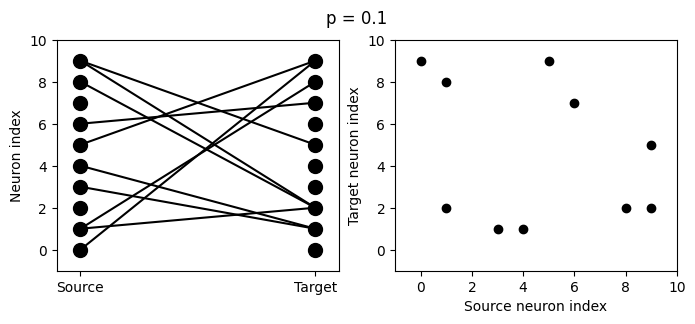

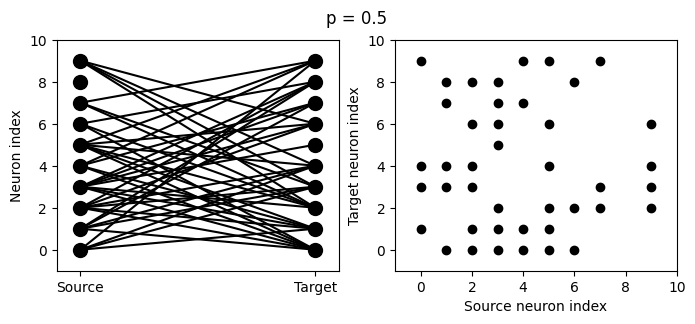

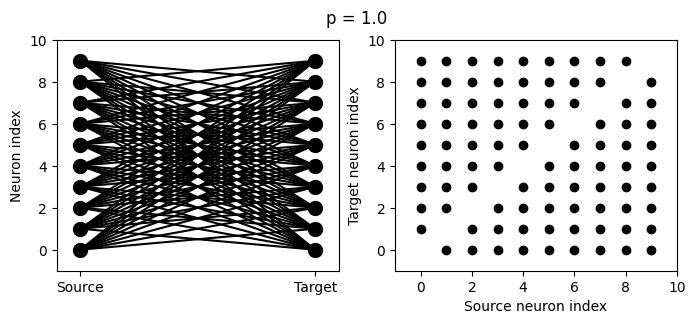

In [9]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

N = 10
group = b2.NeuronGroup(N, 'v:1')

for p in [0.1, 0.5, 1.0]:
    b2.start_scope()
    syn = b2.Synapses(group, group)
    syn.connect(condition = 'i!=j', p = p)
    visualise_connectivity(syn)
    b2.suptitle('p = '+str(p));

It is possible to connect only to neighbouring neurons.

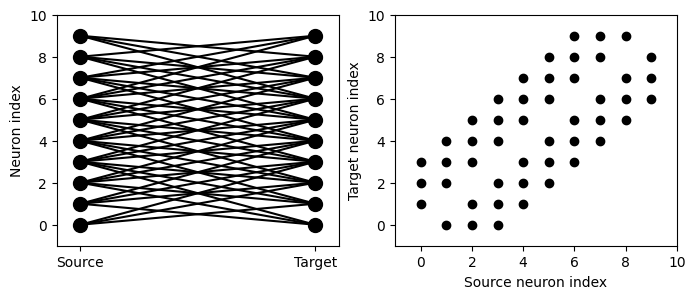

In [10]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

N = 10
group = b2.NeuronGroup(N, 'v:1')
syn = b2.Synapses(group, group)
syn.connect(condition = 'abs(i-j)<4 and i!=j')

visualise_connectivity(syn)

This syntax allows us to create connections more efficiently, which is useful when simulations include large numbers of neurons. 

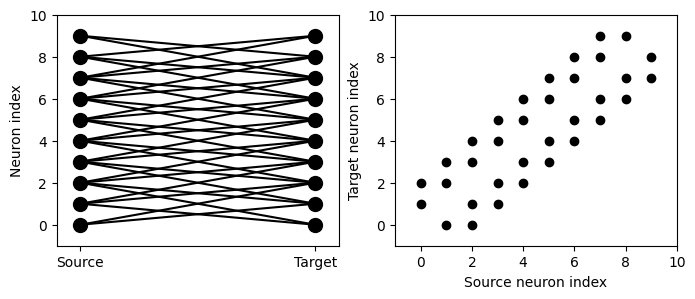

In [11]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

N = 10
group = b2.NeuronGroup(N, 'v:1')
syn = b2.Synapses(group, group)
syn.connect(j = 'k for k in range(i-2, i+3) if i!=k', skip_if_invalid = True)

visualise_connectivity(syn)

It is also possible to specify the value of weights with a string. In this example, we assign each neuron a spatial location and have a distance-dependent connectivity function. We visualise the weight of a synapse by the suze of the marker.

In [12]:
b2.start_scope()

# Neurons 
N = 30
neuron_spacing = 50 * b2.umetre
width = N / 4.0 * neuron_spacing
group = b2.NeuronGroup(N, 'x:metre')
group.x = 'i*neuron_spacing'

# Synapses
syn = b2.Synapses(group, group, 'w:1')
syn.connect(condition = 'i!=j')
# Weight varies with distance
syn.w = 'exp(-2*(x_pre-x_post)**2/(2*width**2))'

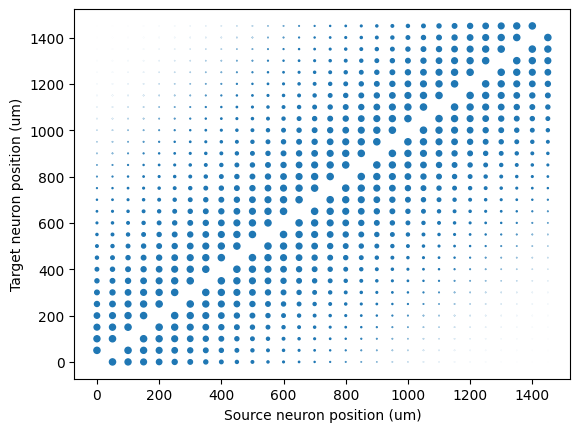

In [13]:
b2.scatter(syn.x_pre / b2.um, syn.x_post / b2.um, syn.w * 20)
b2.xlabel('Source neuron position (um)')
b2.ylabel('Target neuron position (um)');

#### **Spike-timing dependent plasticity**

The variables $a_{\text{pre}}$ and $a_{\text{post}}$ represent the transient changes left behind in the synapse after a spike. 

$$
\tau_{\text{pre}} \frac{d}{dt} a_{\text{pre}} = -a_{\text{pre}}
$$
$$
\tau_{\text{post}} \frac{d}{dt} a_{\text{post}} = -a_{\text{post}}
$$

These are first-order differential equations. In the absence of any spikes, the simply dictate that both traces decay exponentially toward zero over time, governed by its respective time constants. 

- When a presynaptic spike occurs: (1) $a_{\text{pre}} \rightarrow a_{\text{pre}} + A_{\text{pre}}$ (presynaptic trace gets an immediate additive boost, usually a positive value) and (2) $w \rightarrow w + a_{\text{post}}$.
- When a postsynaptic spike occurs: (1) $a_{\text{post}} \rightarrow a_{\text{post}} + A_{\text{post}}$ (postsynaptic trace usually gets a negative boost) and (2) $w \rightarrow w + a_{\text{pre}}$.

When the pre-spike happens before the post-spike, the synapse experiences LTP. On the other hand, when the post-spike happens before the pre-spike, the synapse experiences LTD.

In [24]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

taupre = taupost = 20 * b2.ms
wmax = 0.01
Apre = 0.01
Apost = -Apre * taupre / taupost * 1.05

group = b2.NeuronGroup(2, 'v:1', threshold = 't>(1+i)*10*ms', refractory= 100 * b2.ms)
syn = b2.Synapses(group, group, '''
                  w : 1
                  dapre/dt = -apre/taupre : 1 (clock-driven)
                  dapost/dt = -apost/taupost : 1 (clock-driven)
                  ''',
                  on_pre = '''
                  v_post += w
                  apre += Apre
                  w = clip(w+apost, 0, wmax) ''',
                  on_post= ''' 
                  apost += Apost
                  w = clip(w+apre, 0, wmax) ''', 
                  method='linear')

syn.connect(i = 0, j = 1)
M = b2.StateMonitor(syn, ['w', 'apre', 'apost'], record = True)
b2.run(100 * b2.ms)

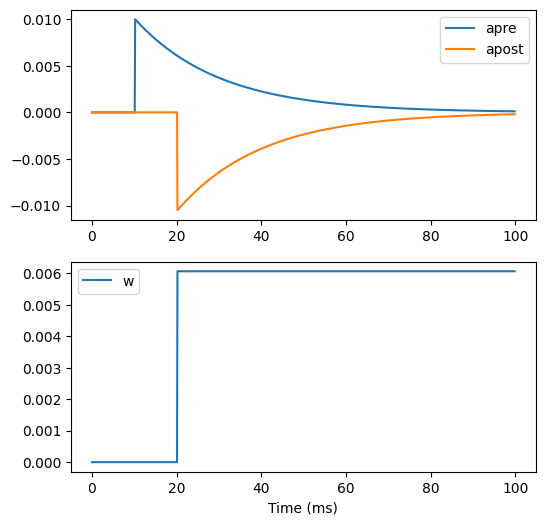

In [25]:
b2.figure(figsize=(6, 6))
b2.subplot(211)
b2.plot(M.t / b2.ms, M.apre[0], label='apre')
b2.plot(M.t/ b2.ms, M.apost[0], label='apost')
b2.legend()
b2.subplot(212)
b2.plot(M.t/ b2.ms, M.w[0], label='w')
b2.legend(loc='best')
b2.xlabel('Time (ms)');

In [34]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

taupre = taupost = 20 * b2.ms
Apre = 0.01
Apost = -Apre * taupre / taupost * 1.05
tmax = 100 * b2.ms
N = 100

# Presynaptic neurons spike at times from zero to tmax 
# Postsynaptic neurons spike at times from tmax to zero
# The difference in spike tipes will vary from -tmax to +tmax

pre = b2.NeuronGroup(N, 'tspike:second', threshold = 't>tspike', refractory = 500 * b2.ms)
post = b2.NeuronGroup(N, 'tspike:second', threshold = 't>tspike', refractory = 500 * b2.ms)
pre.tspike = 'i*tmax/(N-1)'
post.tspike = '(N-1-i)*tmax/(N-1)'

syn = b2.Synapses(pre, post, '''
                  w:1
                  dapre/dt = -apre/taupre : 1 (clock-driven)
                  dapost/dt = -apost/taupost : 1 (clock-driven) ''',
                  on_pre = '''
                  apre += Apre
                  w = w+apost ''',
                  on_post = '''
                  apost += Apost
                  w = w+apre ''',
                  method = 'linear')

syn.connect(j = 'i')
b2.run(tmax + 1 * b2.ms)

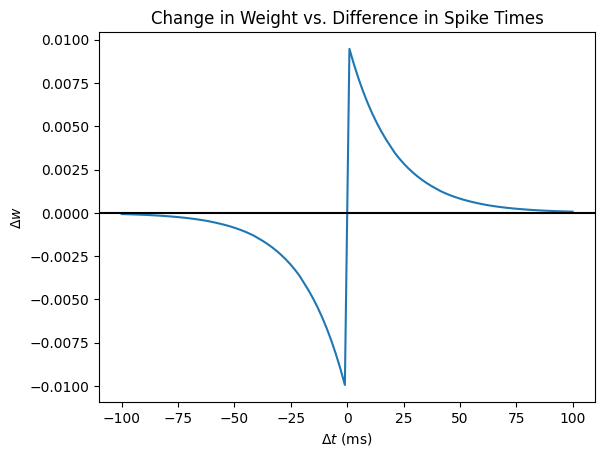

In [37]:
b2.plot((post.tspike - pre.tspike) / b2.ms, syn.w)
b2.xlabel(r'$\Delta t$ (ms)')
b2.ylabel(r'$\Delta w$')
b2.axhline(0, ls = '-', c = 'k')
b2.title('Change in Weight vs. Difference in Spike Times');